In [73]:
import logging
import os
from pathlib import Path
import shutil
from hydra.utils import instantiate
import torch
from argparse import ArgumentParser
from hydra import initialize_config_dir, compose
import math
from accelerate import Accelerator

from torch.utils.data import DataLoader, DistributedSampler, ConcatDataset, Dataset, Subset
from typing import List, Tuple, Any
from safetensors.torch import load_file
import os
import numpy as np
from tqdm import tqdm

In [2]:
def _collect_dataset_configs(experiment_config, prefix: str) -> List[Any]:
    """Берёт все ключи вида train_dataset*, valid_dataset*."""
    return [v for k, v in experiment_config.items() if str(k).startswith(prefix)]

def build_dataset_from_cfgs(dataset_cfgs: List[Any]) -> Dataset:
    """Instantiate -> Dataset or ConcatDataset."""
    datasets = [instantiate(cfg) for cfg in dataset_cfgs]
    if len(datasets) == 0:
        raise ValueError("No datasets after instantiate()")
    if len(datasets) == 1:
        return datasets[0]
    return ConcatDataset(datasets)

In [ ]:
checkpoint = '/workspace-SR003.nfs2/estsoi/TSSprediction/runs/CRE_prediction/checkpoint-31750/model.safetensors'

class modelValidator():
    
    def __init__(self, checkpoint:str, config:str|Path):
        self.checkpoint = checkpoint
        self.config = config
        self.device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
        self.dataset = None
        self.model = None
        self.balanced_indices = None
        self.balanced_dataset = None
        
    def instantiate_model(self):
        if not isinstance(self.config, Path):
            self.config = Path(self.config).absolute()
        with initialize_config_dir(str(self.config.parents[0])):
            experiment_config = compose(config_name=self.config.name)
        model = instantiate(experiment_config['model'])
        
        state_dict = load_file(checkpoint, device="cpu")
        # 3. Load the weights into your model
        model.load_state_dict(state_dict)
        self.model = model

    def instantiate_dataset(self, prefix:str) -> ConcatDataset|Dataset:
        dataset_cfgs = _collect_dataset_configs(experiment_config=self.config, prefix=prefix)
        dataset = build_dataset_from_cfgs(dataset_cfgs=dataset_cfgs)
        self.dataset = dataset

    def select_indices(self) -> list:
        assert isinstance(self.dataset, Dataset|ConcatDataset)
        dataset_len = self.dataset.__len__()
        positive_class = []
        negative_class = []
        for idx in range(dataset_len):
            dataset_entry = self.dataset[idx]
            label = (dataset_entry['labels'] * dataset_entry['labels_mask']).sum()
            if label == 0:
                negative_class.append(idx)
            elif label == 1:
                positive_class.append(idx)
            else:
                raise Exception(f'Invalid label encountered: {label}')
        
        len_negative_class = len(negative_class)
        len_positive_class = len(positive_class)
        
        rng = np.random.default_rng(seed=42)
        
        if len_negative_class > len_positive_class:
            negative_class = rng.choice(negative_class, len_positive_class).tolist()
        
        else:
            positive_class = rng.choice(positive_class, len_positive_class).tolist()
        
        output = negative_class + positive_class
        output.sort()
        
        self.balanced_indices = output
                    

    def balance_classes(self):
        assert self.dataset is not None
        assert self.balanced_indices is not None
        self.balanced_dataset = Subset(self.dataset, indices=self.balanced_indices)
        
    def run_inference(self):
        assert isinstance(self.model, torch.nn.Module)
        assert isinstance(self.dataset, Dataset|ConcatDataset)
        self.model.to(self.device)
        self.model.eval()
        
        self.dataloader = DataLoader(self.dataset, batch_size=20)
        
        with torch.inference_mode(mode=True):
            pass



In [6]:
validator = modelValidator(checkpoint=checkpoint, config='configs/run_config.yaml')

In [ ]:
validator.instantiate_model()
validator.instantiate_dataset(prefix='valid_dataset_CRE')
validator.balance_classes()


/tmp/ipykernel_157440/507621479.py:17: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize_config_dir(str(self.config.parents[0])):


InstantiationException: Error locating target 'CRE_model.CreModel', set env var HYDRA_FULL_ERROR=1 to see chained exception.
full_key: model

In [2]:
import polars as pl

In [41]:
def compute_coverage(df, chrom: str, start: int, end: int) -> float:
    """
    Compute coverage fraction for a region using pre-merged intervals.
    df_merged must have columns: chrom, start, end (non-overlapping)
    """
    region_len = end - start
    if region_len <= 0:
        return 0.0
    subset = (
        df.filter(
            (pl.col("chrom") == chrom) & 
            (pl.col("start") < end) & 
            (pl.col("end") > start)
        )
        .select(
            (pl.col("start").clip(start, end)).alias("s"),
            (pl.col("end").clip(start, end)).alias("e")
        )
    )
    
    print(subset)
    if subset.is_empty():
        return 0.0
    covered_len = (subset["e"] - subset["s"]).sum()
    print(covered_len, 'covered')
    print(region_len, 'total')
    return float(covered_len) / region_len

In [21]:
df = pl.read_csv('/workspace-SR003.nfs2/estsoi/TSSprediction/GENA_LM/downstream_tasks/TSSprediction/data/cre/GRCh38-cCREs.bed', separator='\t', new_columns=['chrom', 'start', 'end', 'idx1', 'idx2', 'type'])

In [23]:
df.with_columns(length = pl.col.end - pl.col.start).sort('length', descending=True)

chrom,start,end,idx1,idx2,type,length
str,i64,i64,str,str,str,i64
"""chr1""",115562,115912,"""EH38F0000002""","""EH38E3951280""","""CA-CTCF""",350
"""chr1""",181289,181639,"""EH38D4327525""","""EH38E2776524""","""CA-H3K4me3""",350
"""chr1""",191294,191644,"""EH38D4327540""","""EH38E2776526""","""dELS""",350
"""chr1""",675363,675713,"""EH38F0000006""","""EH38E3951308""","""TF""",350
"""chr1""",812764,813114,"""EH38F0000008""","""EH38E3951318""","""TF""",350
…,…,…,…,…,…,…
"""chrY""",19590378,19590528,"""EH38F0054204""","""EH38E4535009""","""TF""",150
"""chrY""",19758891,19759041,"""EH38F0054206""","""EH38E4535021""","""TF""",150
"""chrY""",20553280,20553430,"""EH38F0072971""","""EH38E4535070""","""TF""",150


In [6]:
df_merged = merge_intervals(df)

In [17]:
df.filter((pl.col.chrom == 'chr8') & (pl.col.start<1435349) & (pl.col.end > 1425129))

chrom,start,end,idx1,idx2,type
str,i64,i64,str,str,str
"""chr8""",1428587,1428936,"""EH38D4055035""","""EH38E3814137""","""dELS"""
"""chr8""",1429128,1429317,"""EH38D5919941""","""EH38E3814138""","""dELS"""
"""chr8""",1430434,1430603,"""EH38D5919943""","""EH38E3814139""","""CA-CTCF"""
"""chr8""",1431550,1431725,"""EH38D5919944""","""EH38E3814140""","""CA-CTCF"""
"""chr8""",1431826,1432154,"""EH38D5919945""","""EH38E4458690""","""CA"""
"""chr8""",1433249,1433563,"""EH38D5919947""","""EH38E4458691""","""CA"""
"""chr8""",1433810,1433986,"""EH38F0047866""","""EH38E4458692""","""TF"""
"""chr8""",1435307,1435553,"""EH38D4055040""","""EH38E4458693""","""CA"""


In [16]:
df_merged

chrom,start,end
str,i64,i64
"""chr1""",10385,10713
"""chr1""",16097,16381
"""chr1""",17343,17642
"""chr1""",29320,29517
"""chr1""",66350,66509
…,…,…
"""chr7""",10008,159335903
"""chr8""",71103,145076465
"""chr9""",10001,138283286


In [24]:
compute_coverage(df, chrom='chr8', start=1425129, end=1435349)

ColumnNotFoundError: unable to find column "chrom"; valid columns: ["s", "e"]

In [ ]:
coverage_array = []
chroms = df['chrom'].unique()
pbar = tqdm()
for chrom in chroms:
    chrom_df = df.filter(pl.col('chrom')==chrom)
    start = 0
    end = start + 10_000
    while end < df['end'].max():
        coverage = compute_coverage_merged(chrom_df, chrom=chrom, start=start, end=end)
        coverage_array.append(coverage)
        start += 10_000
        end += 10_000
        pbar.update(1)
        
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(data=coverage_array, kde=True)

24894it [06:55, 59.91it/s] 

<Axes: ylabel='Count'>

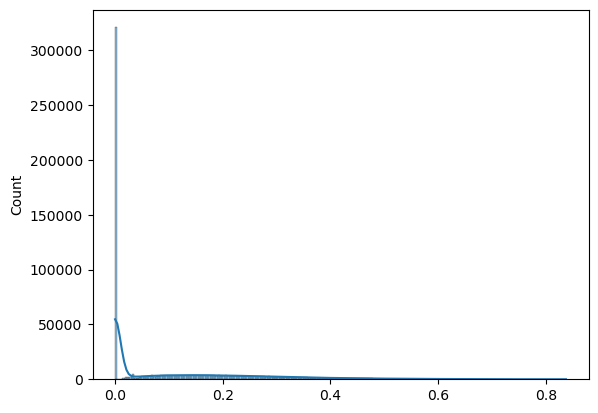

In [2]:
import h5py

In [3]:
h5_cache = h5py.File('/workspace-SR003.nfs2/estsoi/TSSprediction/GENA_LM/downstream_tasks/TSSprediction/cache/CRE_Homo_sapiens_CRE_train.642f636d7e1fe430.h5', 'r')

In [17]:
for i in range(100000):
    print((h5_cache[f'{i}'].attrs['end'] - h5_cache[f'{i}'].attrs['start']))

3650
3766
3819
3761
3664
3512
3699
0
3588
3878
3603
3900
3974
3949
3747
3823
3856
3712
3971
3714
3475
3687
1500
3895
0
0
0
0
3527
3838
3846
3071
3953
3706
4069
4034
4319
2963
2904
3063
3764
3639
3447
3211
3823
3547
3718
3453
3947
3406
3890
3845
3167
3920
0
3428
3295
3499
3848
3682
3529
3768
3503
3268
3752
3472
3648
3387
3403
3606
3541
3688
3523
3492
3402
3806
3595
3599
3572
3212
3470
3576
3535
3288
3332
3605
3530
3446
3587
3421
3453
3404
3691
3822
3202
3428
3598
3897
2760
3817
3743
3344
3731
3073
3595
3581
3738
3681
3577
3302
3921
3499
4225
3908
3662
3960
3566
3787
0
0
3628
3776
3748
3773
3922
4039
4221
4161
3820
4436
3829
3922
4057
4265
3842
3138
3787
3899
3677
3391
3676
3740
3744
3199
0
3495
3574
3317
3550
3194
3442
3624
3287
3321
1681
0
0
3978
3673
4153
3833
4010
3827
3589
3507
3680
3502
3262
3013
3852
3430
3826
3374
3365
3161
3956
3527
4067
4078
4667
4017
3972
3999
3088
3346
3698
3700
3290
0
0
4035
3946
3811
3672
3832
3506
3609
3854
3733
3821
3714
3805
3584
3679
3972
3964
4311
3499

In [107]:
labels = []
idx = 0
while True:
    try:
        labels.append(h5_cache[f'{idx}'].attrs['target'])
        idx += 1
    except:
        break

In [109]:
np.unique(labels, return_counts=True)

(array([False,  True]), array([ 45268, 305750]))

In [ ]:

import logging
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset
from pysam import FastaFile
from pathlib import Path
from transformers import AutoTokenizer

import polars as pl

from typing import List, Dict
import logging
from pathlib import Path
from hydra.utils import instantiate
import torch
from argparse import ArgumentParser
from hydra import initialize_config_dir, compose
from accelerate import Accelerator

from torch.utils.data import DataLoader, DistributedSampler, ConcatDataset, Dataset, Subset
from typing import List, Tuple, Any
from safetensors.torch import load_file
import numpy as np
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

In [ ]:
os.path.basename('path/genome.fasta')

'genome.fasta'

In [ ]:
checkpoint = '/workspace-SR003.nfs2/estsoi/TSSprediction/runs/CRE_prediction/checkpoint-31750/model.safetensors'

class CreInference():
    
    # chrom, start, end, genome  -- if input as mappings
    # chrom, start, end - if single genome
    
    def __init__(self, checkpoint:str, 
                    tokenizer:str, 
                    config:str,
                    genome:str|None = None,
                    file_mappings:str|None = None,
                    max_seq_len:int = 1024,
                    token_len_for_fetch:int = 10
                    ):
        self.checkpoint = checkpoint
        self.config = config
        if genome:
            self.genome = genome
            self.single_input = True
        if file_mappings:
            self.file_mappings = file_mappings
            self.single_input = False
        self.model = None
        self.tokenizer = AutoTokenizer.from_pretrained(tokenizer, trust_remote_code=True)
        
        
        self.token_len_for_fetch = token_len_for_fetch
        
        self.cls_id = self.tokenizer.cls_token_id
        self.sep_id = self.tokenizer.sep_token_id
        self.pad_id = self.tokenizer.pad_token_id
        
        self.num_special_tokens = 2
        self.max_seq_len = max_seq_len
        self.interval_len_tokens = self.max_seq_len - self.num_special_tokens
        
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        logging.basicConfig(
            format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
            level=logging.INFO
        )
        self.logger = logging.getLogger(__name__)   
        
    def encode_taxon(self, taxon) -> int:
        mapping = {'Unknown': 0,
                    "Lepidosauria": 1,
                    "Chondrichthyes": 2,
                    "Mammalia": 3,
                    "Amphibia": 4,
                    "Actinopteri": 5,
                    "Myxini": 6,
                    "Aves": 7}
        
        return mapping[taxon] if taxon in mapping else mapping['Unknown']
             
    def instantiate_model(self):
        self.logger.info('INSTANTIATING MODEL')
        if not isinstance(self.config, Path):
            self.config = Path(self.config).absolute()
        with initialize_config_dir(str(self.config.parents[0])):
            experiment_config = compose(config_name=self.config.name)
            self.config_dict = experiment_config
        model = instantiate(experiment_config['model'])
        
        state_dict = load_file(checkpoint, device="cpu")
        # 3. Load the weights into your model
        model.load_state_dict(state_dict)
        self.model = model
        
    def compute_encoded_seq_len(self, tokens, mapping):
        
        tokenized_sequence_len = 0
        for i, (start, end) in enumerate(mapping):
            token_id = tokens[i]
            if token_id == 5:
                if i > 0:
                    token_len = end - mapping[i-1][1]
                else:
                    token_len = end
            else:
                token_len = end - start
                
            tokenized_sequence_len += token_len
        return tokenized_sequence_len
        
    def process_single_genome(self, genomePath:str, taxon:str):
        
        
        
        assert isinstance(self.model, torch.nn.Module)
        self.model.to(self.device)
        self.model.eval()
        
        with torch.inference_mode():
            
            with FastaFile(genomePath) as genome:
                
                for chrom in genome.references:
                    chrom_len = genome.get_reference_length(chrom)
                    start = 0
                    while start < chrom_len:
                        end = min(start+self.interval_len_tokens*self.token_len_for_fetch, chrom_len)
                        sequence = genome.fetch(chrom, start, end).upper()
                        
                        encoded_sequence = self.tokenizer.encode_plus(sequence, return_offsets_mapping=True)
                        encoded_sequence['input_ids'] = encoded_sequence['input_ids'][1:-1]
                        encoded_sequence['offset_mapping'] = encoded_sequence['offset_mapping'][1:-1]
                        
                        if encoded_sequence['input_ids'].__len__() < self.interval_len_tokens:
                            #self.logger.warning(f"len of token sequence {encoded_sequence['input_ids'].__len__()} is less then {self.interval_len_tokens}")
                            pass
                            
                        mapping = encoded_sequence['offset_mapping'][0:self.interval_len_tokens]
                        tokens = encoded_sequence['input_ids'][0:self.interval_len_tokens]
                        
                        tokenized_sequence_len = self.compute_encoded_seq_len(tokens, mapping)
                        
                        taxon_encoded = self.encode_taxon(taxon)
                        
                        seq_ids = [self.cls_id] + tokens.tolist() + [self.sep_id]
                        seq_len = len(seq_ids)
                        if seq_len < self.max_seq_len:
                            pad_len = self.max_seq_len - seq_len
                            seq_ids += [self.pad_id] * pad_len
                            attn_mask = [1] * seq_len + [0] * pad_len
                        else:
                            attn_mask = [1] * self.max_seq_len
                            
                        input_ids = torch.tensor(seq_ids, dtype = torch.long)
                        attention_mask = torch.tensor(attn_mask, dtype = torch.long)
                        
                        labels = torch.zeros(self.max_seq_len, 1, dtype=torch.float32)
                        labels_mask = torch.zeros(self.max_seq_len, 1, dtype = torch.bool)
                        
                        labels[0, 0] = 0.0
                        labels_mask[0, 0] = True
                        
                        model_output = self.model(
                                                    input_ids=input_ids,
                                                    attention_mask=attention_mask,
                                                    labels_mask=labels_mask,
                                                    labels=labels,
                                                    taxon=taxon_encoded
                                                )
                        
                        predict_raw = model_output.predicts[:, 0:1, :].unsqueeze(-1)
                        predict = (torch.sigmoid(predict_raw) > 0.5).cpu().numpy().flatten()
                        
                        region_results = (chrom, start, end, predict.item())
                        print(region_results)
                        
                        
                        start += tokenized_sequence_len
                        
    def run(self):
        self.process_single_genome(genomePath=self.genome, taxon='Mammalia')
                        
                        
tokenizer = '/workspace-SR003.nfs2/estsoi/TSSprediction/GENA_LM/data/tokenizers/t2t_1000h_multi_32k'

predictor = CreInference(checkpoint=checkpoint,
                tokenizer=tokenizer,
                genome='data/cre/genomes_cre/hg38.fa',
                config = '/workspace-SR003.nfs2/estsoi/TSSprediction/GENA_LM/downstream_tasks/TSSprediction/configs/cre_test_config.yaml')                 
predictor.instantiate_model()

predictor.run()
            

                    
                    


In [11]:
tokenizer = '/workspace-SR003.nfs2/estsoi/TSSprediction/GENA_LM/data/tokenizers/t2t_1000h_multi_32k'

predictor = CreInference(checkpoint=checkpoint,
                tokenizer=tokenizer,
                genome='data/cre/genomes_cre/hg38.fa',
                config = '/workspace-SR003.nfs2/estsoi/TSSprediction/GENA_LM/downstream_tasks/TSSprediction/configs/cre_test_config.yaml')

In [12]:
predictor.instantiate_model()

2026-04-14 17:01:02,362 - __main__ - INFO - INSTANTIATING MODEL
/tmp/ipykernel_3551300/1197517680.py:61: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize_config_dir(str(self.config.parents[0])):


InstantiationException: Error locating target 'CRE_model.CreModel', set env var HYDRA_FULL_ERROR=1 to see chained exception.
full_key: model

In [15]:
import polars as pl
import numpy as np
import os
import json


class Metadata():
    
    def __init__(self, 
                sample2genome:str = 'metadata/file_mappings.csv',
                sample2taxon:str = 'metadata/sample2taxonType.json',
                genomesDIR:str = 'data/genomes/',
                genomes_decompressed:bool = True,
                ):
        
        self.genomesDIR = genomesDIR
        
        for file, path in { 
            'sample2genome': sample2genome,
            'sample2taxon': sample2taxon
        }.items():
            assert os.path.exists(path), f'File does not exist: {file}'
            
        for dir, path in {
            'genomesDIR' : genomesDIR,
        }.items():
            assert os.path.isdir(path), f'Dir does not exist: {dir}'
        

        self.sample2genomePath = pl.read_csv(sample2genome) \
                                .select('id', 'genome') \
                                .with_columns(genomePath = genomesDIR + pl.col('genome').str.split('/').list.gather([-1]).list.join(''))
        
        with open(sample2taxon, 'r') as json_handle:
            self.sample2taxon = json.load(json_handle)
            
        self.final_metadata = self.sample2genomePath.with_columns(taxon = pl.col('id').replace_strict(self.sample2taxon)) #id, ScientificName, genome_acc, annotation, genomePath, taxon
        if genomes_decompressed:
            self.final_metadata = self.final_metadata.with_columns(pl.col('genomePath').str.strip_suffix('.gz'))
        
        
        self.condensed_metadata = self.final_metadata.unique('genomePath').select('genomePath', 'taxon')
        
        
    def write(self, format:str, out_path:str='metadata/'):
        if format == 'full':
            self.final_metadata.write_csv(os.path.join(out_path, 'full_metadata.csv'))
        elif format == 'condensed':
            self.condensed_metadata.write_csv(os.path.join(out_path, 'genome2taxon.csv'))

In [16]:
Metadata().write('condensed')

In [11]:
def get_gpu_utilization():
    import pynvml
    pynvml.nvmlInit()
    for gpu in range(torch.cuda.device_count()):
        handle = pynvml.nvmlDeviceGetHandleByIndex(gpu)
        util = pynvml.nvmlDeviceGetUtilizationRates(handle)
        print(f"Cuda:{gpu} Utilization: {util.gpu}%")

In [12]:
get_gpu_utilization()

Cuda:0 Utilization: 100%
Cuda:1 Utilization: 100%
Cuda:2 Utilization: 100%
Cuda:3 Utilization: 100%
Cuda:4 Utilization: 100%
Cuda:5 Utilization: 0%
Cuda:6 Utilization: 0%


In [2]:
import polars as pl

In [8]:
(pl.read_csv('/workspace-SR003.nfs2/estsoi/TSSprediction/GENA_LM/downstream_tasks/TSSprediction/file_mappings.csv') \
    .with_columns((pl.col.genome.str.replace('genomes', 'intervals')
                   .str.strip_suffix('.fasta.gz') + pl.lit('.forward.csv')).alias('forward_intervals'))
    .with_columns((pl.col.genome.str.replace('genomes', 'intervals')
                   .str.strip_suffix('.fasta.gz') + pl.lit('.reverse.csv')).alias('reverse_intervals'))
    .with_columns(pl.lit('multispeciesATAC-seq').alias('dataset_description'))
).write_csv('/workspace-SR003.nfs2/estsoi/TSSprediction/GENA_LM/downstream_tasks/TSSprediction/file_mappings.csv.tmp')

In [10]:
import polars as pl

# Create a test DataFrame with overlapping and non‑overlapping windows
df = pl.DataFrame({
    "chrom": ["chr1", "chr1", "chr1", "chr1", "chr2", "chr2", "chr2", "chr2"],
    "start": [10, 15, 30, 45, 5, 12, 20, 25],
    "end":   [20, 25, 40, 50, 10, 15, 30, 35]
})

In [19]:
import polars as pl

def merge_intervals(df: pl.DataFrame) -> pl.DataFrame:
    """
    Merge overlapping intervals within each chromosome.
    Assumes DataFrame has columns: 'chrom', 'start', 'end'.
    """
    if df.is_empty():
        return df

    return (
        df.sort(["chrom", "start"])
        .with_columns(
            # Running maximum of 'end' within each chromosome
            running_max_end=pl.col("end").cum_max().over("chrom")
        )
        .with_columns(
            # Previous running max (null for the first interval in each chrom)
            prev_running_max=pl.col("running_max_end").shift(1).over("chrom")
        )
        .with_columns(
            # Mark new merged intervals: True when current start > previous running max
            is_new_group=pl.when(pl.col("prev_running_max").is_null())
                          .then(True)
                          .otherwise(pl.col("start") > pl.col("prev_running_max"))
        )
        .with_columns(
            # Cumulative sum of markers creates a unique ID for each merged interval
            group_id=pl.col("is_new_group").cum_sum().over("chrom")
        )
        .group_by(["chrom", "group_id"])
        .agg(
            pl.min("start").alias("start"),
            pl.max("end").alias("end")
        )
        .drop("group_id")
        .sort(["chrom", "start"])
        .select(["chrom", "start", "end"]) # Ensure consistent column order
    )

In [17]:
def merge_intervals(df:pl.DataFrame):
    df = df.sort('chrom', 'start', descending=False)
    merged_intervals = []
    previous_row = None
    for row in df.iter_rows(named=True):
        if previous_row is None:
            previous_row = row
            continue
        else:
            if previous_row['chrom'] == row['chrom']:
                if previous_row['end'] > row['start']:
                    previous_row['end'] = row['end']
                else:
                    merged_intervals.append(previous_row)
                    previous_row = row
    return pl.DataFrame(merged_intervals)

In [47]:
def compute_coverage(df, chrom: str, start: int, end: int) -> float:
    """
    Compute coverage fraction for a region using pre-merged intervals.
    df_merged must have columns: chrom, start, end (non-overlapping)
    """
    region_len = end - start
    if region_len <= 0:
        return 0.0
    subset = (
        df.filter(
            (pl.col("chrom") == chrom) & 
            (pl.col("start") < end) & 
            (pl.col("end") > start)
        )
        .select(
            (pl.col("start").clip(start, end)).alias("s"),
            (pl.col("end").clip(start, end)).alias("e")
        )
    )
    
    if subset.is_empty():
        return 0.0
    covered_len = (subset["e"] - subset["s"]).sum()
    return float(covered_len) / region_len

In [27]:
df = pl.read_csv('/workspace-SR003.nfs2/estsoi/TSSprediction/GENA_LM/downstream_tasks/TSSprediction/data/cre/GRCh38-cCREs.bed', separator='\t', new_columns=['chrom', 'start', 'end', 'idx1', 'idx2', 'type'])

In [36]:
df_merged = (df.sort(["chrom", "start"])
        .with_columns(
            # Running maximum of 'end' within each chromosome
            running_max_end=pl.col("end").cum_max().over("chrom")
        )
        .with_columns(
            # Previous running max (null for the first interval in each chrom)
            prev_running_max=pl.col("running_max_end").shift(1).over("chrom")
        )
        .with_columns(
            # Mark new merged intervals: True when current start > previous running max
            is_new_group=pl.when(pl.col("prev_running_max").is_null())
                          .then(True)
                          .otherwise(pl.col("start") > pl.col("prev_running_max"))
        )
        .with_columns(
            # Cumulative sum of markers creates a unique ID for each merged interval
            group_id=pl.col("is_new_group").cum_sum().over("chrom")
        )
        .group_by(["chrom", "group_id"])
        .agg(
            pl.min("start").alias("start"),
            pl.max("end").alias("end")
        )
        .sort(["chrom", "start"])
        .select(["chrom", "start", "end"]) # Ensure consistent column order
    )

In [40]:
df_merged

chrom,start,end
str,i64,i64
"""chr1""",10385,10713
"""chr1""",16097,16381
"""chr1""",17343,17642
"""chr1""",29320,29517
"""chr1""",66350,66509
…,…,…
"""chrY""",26670948,26671287
"""chrY""",26671292,26671478
"""chrY""",26671538,26671787


In [43]:
compute_coverage(df, chrom='chr8', start=1425129, end=1435349)

shape: (8, 2)
┌─────────┬─────────┐
│ s       ┆ e       │
│ ---     ┆ ---     │
│ i64     ┆ i64     │
╞═════════╪═════════╡
│ 1428587 ┆ 1428936 │
│ 1429128 ┆ 1429317 │
│ 1430434 ┆ 1430603 │
│ 1431550 ┆ 1431725 │
│ 1431826 ┆ 1432154 │
│ 1433249 ┆ 1433563 │
│ 1433810 ┆ 1433986 │
│ 1435307 ┆ 1435349 │
└─────────┴─────────┘
1742 covered
10220 total


0.17045009784735812

In [25]:
merge_intervals(df).with_columns(length = pl.col.end - pl.col.start).sort('length', descending=True)

chrom,start,end,length
str,i64,i64,i64
"""chr12""",127429255,127430254,999
"""chr10""",75733065,75734019,954
"""chr12""",130513545,130514482,937
"""chr3""",61724239,61725170,931
"""chr8""",91107873,91108801,928
…,…,…,…
"""chrY""",19590378,19590528,150
"""chrY""",19758891,19759041,150
"""chrY""",20553280,20553430,150


2970it [00:05, 522.37it/s]


150it [00:00, 752.18it/s]

chr5


26019it [00:41, 609.79it/s]

chr3


...

chr2


416687it [09:35, 615.28it/s]

chr6


440906it [10:09, 796.50it/s]

<Axes: ylabel='Count'>

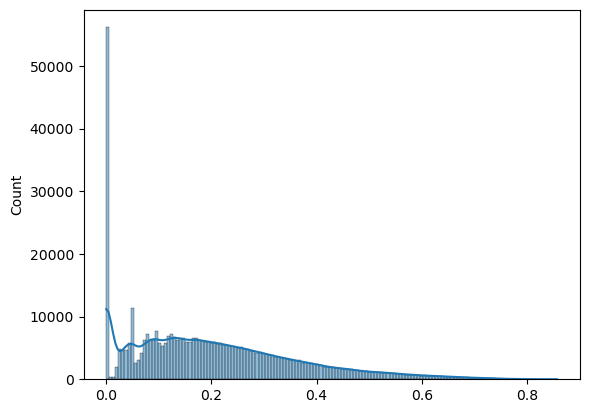

In [51]:
from tqdm import tqdm
coverage_array = []
chroms = df['chrom'].unique()
pbar = tqdm()
for chrom in chroms:
    chrom_len = chrom_df['end'].max()
    print(chrom)
    chrom_df = df.filter(pl.col('chrom')==chrom)
    start = 0
    end = start + 7_000
    while end < chrom_len:
        coverage = compute_coverage(chrom_df, chrom=chrom, start=start, end=end)
        coverage_array.append(coverage)
        start += 7_000
        end += 7_000
        pbar.update(1)
        
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(data=coverage_array, kde=True)

In [ ]:
import h5py
file = h5py.File('/workspace-SR003.nfs2/estsoi/TSSprediction/GENA_LM/downstream_tasks/TSSprediction/cache/TSS_Ambystoma_mexicanum_train.642f636d7e1fe430.h5')

In [ ]:
file = h5py.File('/workspace-SR003.nfs2/estsoi/TSSprediction/GENA_LM/downstream_tasks/TSSprediction/cache/TSS_Ambystoma_mexicanum_train.642f636d7e1fe430.h5')

In [ ]:
file.shape